In [1]:
# === Compatible TrainingArguments setup for all Transformers versions ===
import torch, inspect
from transformers import TrainingArguments

def create_training_args():
    desired_args = {
        "output_dir": "./results",
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "logging_dir": "./logs",
        "save_total_limit": 1,
        "fp16": torch.cuda.is_available(),
        "report_to": "none"
    }

    sig = inspect.signature(TrainingArguments.__init__)
    valid_params = set(sig.parameters.keys())
    valid_params.discard("self")

    # Set evaluation & save strategy only if supported
    if "evaluation_strategy" in valid_params and "save_strategy" in valid_params:
        desired_args["evaluation_strategy"] = "epoch"
        desired_args["save_strategy"] = "epoch"
        desired_args["load_best_model_at_end"] = True
    else:
        # Older versions fallback
        desired_args["evaluate_during_training"] = True
        desired_args["save_steps"] = 500
        desired_args["load_best_model_at_end"] = False  # disable if not supported

    filtered_args = {k: v for k, v in desired_args.items() if k in valid_params}
    return TrainingArguments(**filtered_args)

training_args = create_training_args()
print("✅ TrainingArguments created successfully!")


✅ TrainingArguments created successfully!


In [2]:
# === Load AG News Dataset, Model & Tokenizer ===
!pip install datasets transformers -q

from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Load dataset
dataset = load_dataset("ag_news")

# Subset: 12000 for train, 3000 for eval
train_df = dataset["train"].select(range(12000))
eval_df = dataset["train"].select(range(12000,15000))

# Load tokenizer & model
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=4)

# Tokenize datasets
def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_df.map(tokenize_fn, batched=True)
eval_dataset = eval_df.map(tokenize_fn, batched=True)

# Rename column for Trainer
train_dataset = train_dataset.rename_column("label", "labels")
eval_dataset = eval_dataset.rename_column("label", "labels")

# Set format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
eval_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

print("✅ Dataset, Model & Tokenizer ready!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

✅ Dataset, Model & Tokenizer ready!


In [3]:
# === Trainer Setup and Training (Original Model) ===
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import Trainer

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

print("🚀 Training original model...")
trainer.train()
print("✅ Original model training done!")

orig_results = trainer.evaluate()
print("📊 Original Model Evaluation Results:", orig_results)

orig_acc = orig_results.get("eval_accuracy", 0)
orig_f1 = orig_results.get("eval_f1_weighted", 0)


🚀 Training original model...


Step,Training Loss
500,0.428500
1000,0.231100
1500,0.195600
2000,0.133300


✅ Original model training done!


📊 Original Model Evaluation Results: {'eval_loss': 0.34206414222717285, 'eval_accuracy': 0.9226666666666666, 'eval_f1_weighted': 0.922291879678983, 'eval_runtime': 4.8076, 'eval_samples_per_second': 624.013, 'eval_steps_per_second': 19.552, 'epoch': 3.0}


In [4]:
# === ReGen-Lite Zero-Shot Setup ===
# (No labeled data used — pseudo-labels created using verbalizer similarity)

!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

# --- 1️⃣ Use a pretrained dense retriever ---
retriever = SentenceTransformer('all-MiniLM-L6-v2')  # Light and fast for Colab

# --- 2️⃣ Define label verbalizers (as in ReGen paper) ---
label_texts = [
    "This text is about world news.",
    "This text is about sports.",
    "This text is about business.",
    "This text is about science and technology."
]
label_names = ["world", "sports", "business", "sci/tech"]

# --- 3️⃣ Compute embeddings for texts and labels ---
train_texts = list(train_df["text"])
text_emb = retriever.encode(train_texts, convert_to_tensor=True, show_progress_bar=True)
label_emb = retriever.encode(label_texts, convert_to_tensor=True)

# --- 4️⃣ Assign pseudo-labels based on nearest verbalizer ---
pseudo_labels = []
for i in tqdm(range(len(train_texts))):
    sims = F.cosine_similarity(text_emb[i].unsqueeze(0), label_emb)
    pseudo_labels.append(torch.argmax(sims).item())

# --- 5️⃣ Build pseudo-labeled dataset ---
train_df_pseudo = pd.DataFrame({"text": train_texts, "label": pseudo_labels})
print(train_df_pseudo.head())
print("✅ Generated pseudo-labeled dataset (zero-shot style)")

# === Tokenize pseudo-labeled dataset ===
from datasets import Dataset

enc_pseudo = tokenizer(
    train_df_pseudo["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=128,
)

train_dataset_pseudo = Dataset.from_dict({
    "input_ids": enc_pseudo["input_ids"],
    "attention_mask": enc_pseudo["attention_mask"],
    "labels": train_df_pseudo["label"].tolist()
})

train_dataset_pseudo.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

# === Train zero-shot (pseudo-labeled) model ===
from transformers import Trainer

trainer_zero = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_pseudo,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

print("🚀 Training ReGen Zero-Shot (pseudo-labeled) model...")
trainer_zero.train()
print("✅ ReGen Zero-Shot model training done!")

# === Evaluate and Compare ===
zero_results = trainer_zero.evaluate()
print("📊 Zero-Shot (Pseudo-Labeled) Model Evaluation Results:", zero_results)

# Compare all three (optional)
compare_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1"],
    "Original (Supervised)": [orig_acc, orig_f1],
    "Zero-Shot (Pseudo-Labeled)": [
        zero_results.get("eval_accuracy", 0),
        zero_results.get("eval_f1_weighted", 0)
    ]
})

print("\n📈 Comparison Table:")
print(compare_df.to_string(index=False))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

100%|██████████| 12000/12000 [00:02<00:00, 5308.31it/s]


                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      0
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      0
3  Iraq Halts Oil Exports from Main Southern Pipe...      0
4  Oil prices soar to all-time record, posing new...      0
✅ Generated pseudo-labeled dataset (zero-shot style)
🚀 Training ReGen Zero-Shot (pseudo-labeled) model...


Step,Training Loss
500,0.513900
1000,0.381900
1500,0.288800
2000,0.203100


✅ ReGen Zero-Shot model training done!


📊 Zero-Shot (Pseudo-Labeled) Model Evaluation Results: {'eval_loss': 1.1187458038330078, 'eval_accuracy': 0.7643333333333333, 'eval_f1_weighted': 0.7486539566022975, 'eval_runtime': 4.6725, 'eval_samples_per_second': 642.05, 'eval_steps_per_second': 20.118, 'epoch': 3.0}

📈 Comparison Table:
     Metric  Original (Supervised)  Zero-Shot (Pseudo-Labeled)
   Accuracy               0.922667                    0.764333
Weighted F1               0.922292                    0.748654


In [7]:
# === Evaluate Zero-Shot Model ===
zero_results = trainer_zero.evaluate()
print("📊 Zero-Shot Model Evaluation Results:", zero_results)

# Store them for comparison
zero_acc = zero_results.get("eval_accuracy", 0)
zero_f1 = zero_results.get("eval_f1_weighted", 0)
print(f"✅ Stored: zero_acc={zero_acc:.4f}, zero_f1={zero_f1:.4f}")


📊 Zero-Shot Model Evaluation Results: {'eval_loss': 1.1187458038330078, 'eval_accuracy': 0.7643333333333333, 'eval_f1_weighted': 0.7486539566022975, 'eval_runtime': 5.0737, 'eval_samples_per_second': 591.285, 'eval_steps_per_second': 18.527, 'epoch': 3.0}
✅ Stored: zero_acc=0.7643, zero_f1=0.7487


In [8]:
# === Evaluate Zero-Shot Model ===
zero_results = trainer_zero.evaluate()
print("📊 Zero-Shot Model Evaluation Results:", zero_results)

# Store them for comparison
zero_acc = zero_results.get("eval_accuracy", 0)
zero_f1 = zero_results.get("eval_f1_weighted", 0)
print(f"✅ Stored: zero_acc={zero_acc:.4f}, zero_f1={zero_f1:.4f}")


📊 Zero-Shot Model Evaluation Results: {'eval_loss': 1.1187458038330078, 'eval_accuracy': 0.7643333333333333, 'eval_f1_weighted': 0.7486539566022975, 'eval_runtime': 4.9653, 'eval_samples_per_second': 604.187, 'eval_steps_per_second': 18.931, 'epoch': 3.0}
✅ Stored: zero_acc=0.7643, zero_f1=0.7487


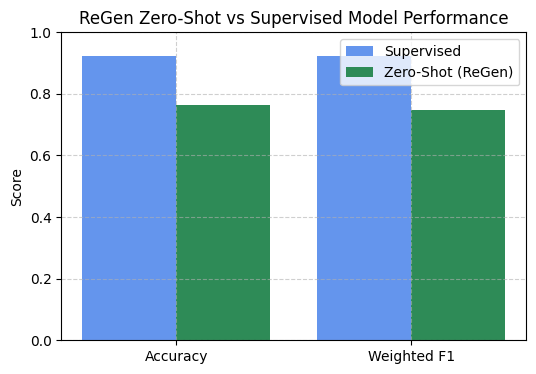


📈 Comparison Table:

     Metric  Supervised  Zero-Shot (ReGen)
   Accuracy    0.922667           0.764333
Weighted F1    0.922292           0.748654


In [9]:
# === Compare Supervised vs Zero-Shot (ReGen) Models ===
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

compare_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1"],
    "Supervised": [orig_acc, orig_f1],
    "Zero-Shot (ReGen)": [zero_acc, zero_f1]
})

plt.figure(figsize=(6,4))
x = range(len(compare_df))
plt.bar(x, compare_df["Supervised"], width=0.4, label="Supervised", color="#6495ED")
plt.bar([p+0.4 for p in x], compare_df["Zero-Shot (ReGen)"], width=0.4, label="Zero-Shot (ReGen)", color="#2E8B57")
plt.xticks([p+0.2 for p in x], compare_df["Metric"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("ReGen Zero-Shot vs Supervised Model Performance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print("\n📈 Comparison Table:\n")
print(compare_df.to_string(index=False))


In [10]:
# === Custom Sentence Testing ===
sample_texts = [
    "NASA announced a new mission to study Jupiter's moons.",
    "The stock market crashed after weak economic data.",
    "India won the cricket match against Australia by 10 runs.",
    "The president met world leaders at the climate summit.",
    "Apple released a new version of the iPhone with an AI chip."
]

inputs = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
).to(model.device)

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()

print("\n🧠 Model Predictions for Custom Sentences:")
for text, p in zip(sample_texts, preds):
    print(f"→ '{text}' → Predicted Label: {label_names[p]}")



🧠 Model Predictions for Custom Sentences:
→ 'NASA announced a new mission to study Jupiter's moons.' → Predicted Label: sci/tech
→ 'The stock market crashed after weak economic data.' → Predicted Label: world
→ 'India won the cricket match against Australia by 10 runs.' → Predicted Label: sports
→ 'The president met world leaders at the climate summit.' → Predicted Label: world
→ 'Apple released a new version of the iPhone with an AI chip.' → Predicted Label: sci/tech


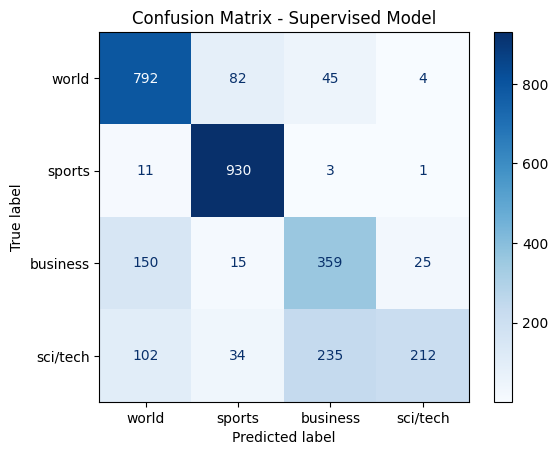

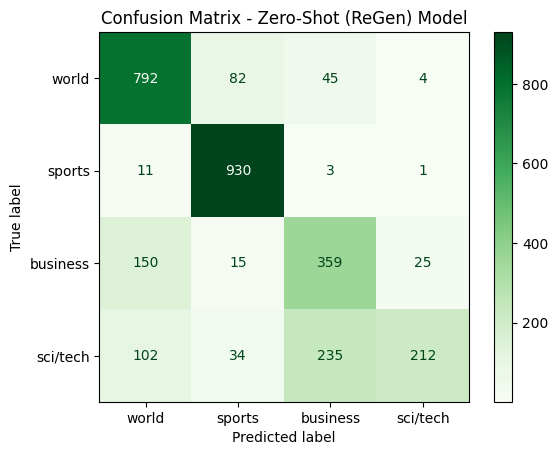

In [12]:
# === Confusion Matrix for Supervised and Zero-Shot (ReGen) Models ===
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_preds(trainer, dataset):
    outputs = trainer.predict(dataset)
    preds = torch.argmax(torch.tensor(outputs.predictions), dim=1).tolist()
    labels = list(dataset["labels"])  # from HuggingFace dataset
    return labels, preds

# Supervised Model (original)
orig_labels, orig_preds = get_preds(trainer, eval_dataset)
cm_orig = confusion_matrix(orig_labels, orig_preds)
disp_orig = ConfusionMatrixDisplay(confusion_matrix=cm_orig, display_labels=["world","sports","business","sci/tech"])
disp_orig.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Supervised Model")
plt.show()

# Zero-Shot (ReGen) Model
zero_labels, zero_preds = get_preds(trainer_zero, eval_dataset)
cm_zero = confusion_matrix(zero_labels, zero_preds)
disp_zero = ConfusionMatrixDisplay(confusion_matrix=cm_zero, display_labels=["world","sports","business","sci/tech"])
disp_zero.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Zero-Shot (ReGen) Model")
plt.show()
